In [35]:
import pandas as pd
import os
from utils.ml_utils import PreprocessingUtils, GBEmissionsPredictionPipeline, RFEmissionsPredictionPipeline
from utils.eda_utils import EDAUtils, DataCleaningUtils
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
SCRIPT_DIR_PATH = os.getcwd()
ROOT_DIR_PATH = os.path.dirname(SCRIPT_DIR_PATH)
DATA_DIR_PATH = os.path.join(ROOT_DIR_PATH, "data")
MAPPING_DIR_PATH = os.path.join(DATA_DIR_PATH, "mapping")
PREDICTORS_DIR_PATH = os.path.join(DATA_DIR_PATH, "predictors")
SSP_DIR_PATH = os.path.join(DATA_DIR_PATH, "ssp")
SIMULATION_DIR_PATH = os.path.join(SSP_DIR_PATH, "sisepuede_run_2025-01-14T17;04;06.975301_output_database")
TRAINING_DIR_PATH = os.path.join(DATA_DIR_PATH, "training")

In [4]:
TRAINING_DATA_PATH = os.path.join(TRAINING_DIR_PATH, "training_data_v2.csv")
training_df = pd.read_csv(TRAINING_DATA_PATH)
training_df = training_df.drop(columns=["primary_id", "future_id"])
training_df.head()

,group_1_ef_lvst_entferm,group_2_yf_agrc,group_3_demscalar_soil,group_4_demscalar_ippu,group_5_efficfactor_enfu_industrial_energy_fuel,group_6_elecfuelefficiency_trns,group_7_factor_waso_waste_per_capita_scalar_food,group_8_frac_fgtv,group_9_frac_agrc_agriculture_production_lost,group_10_frac_agrc,...,group_40_pij_lndu_grasslands+,group_41_pij_lndu_other_to,group_42_pij_lndu_settlements_to,group_43_pij_lndu_wetlands_to,group_44_ef_agrc_anaerobicdom_rice_kg_ch4_ha,group_45_scalar_lvst_carrying_capacity,group_46_scalar_scoe_appliance_energy_demand,group_47_scalar_scoe_heat_energy_demand,total_positive_emissions,total_negative_emissions
0,0.952436,0.360397,0.202990,0.995748,0.369859,0.919920,0.478450,0.445798,0.490988,0.510280,...,0.289038,0.996557,0.053597,0.175103,0.379422,0.438093,0.149362,0.869757,902.639418,-232.131775
1,0.304955,0.204875,0.540658,0.800192,0.206396,0.777352,0.805727,0.536048,0.779857,0.623335,...,0.536533,0.385371,0.246165,0.101025,0.717013,0.368791,0.774941,0.483352,724.378452,-119.927915
2,0.609262,0.366443,0.601808,0.916668,0.386475,0.181162,0.138910,0.768925,0.884425,0.232722,...,0.533412,0.601590,0.122444,0.653845,0.216259,0.714853,0.881270,0.581230,704.191065,-228.482434
3,0.815313,0.487444,0.323954,0.634299,0.064625,0.926815,0.633805,0.439346,0.027114,0.532020,...,0.264120,0.938985,0.592915,0.564895,0.027725,0.138890,0.820709,0.250616,947.002903,-188.998568
4,0.973878,0.842718,0.884382,0.483039,0.455502,0.003343,0.571994,0.108021,0.346714,0.892123,...,0.430582,0.492564,0.432240,0.662820,0.179231,0.631375,0.395960,0.661637,833.854631,-233.083200


In [5]:
# Set some parameters
use_pca = False

## EDA

In [6]:
edau = EDAUtils()

In [8]:
emission_cols = [col for col in training_df.columns if "emissions" in col]
emission_cols

['total_positive_emissions', 'total_negative_emissions']

In [9]:
lhs_group_cols = [col for col in training_df.columns if col.startswith("group_")]
# lhs_group_cols

In [10]:
training_df[emission_cols].describe()

,total_positive_emissions,total_negative_emissions
count,1.000000e+03,1000.000000
mean,7.692947e+05,-198.684887
std,1.071673e+07,39.666845
min,5.997939e+02,-287.044374
25%,8.334354e+02,-231.329991
50%,9.174914e+02,-196.380145
75%,9.983118e+02,-168.603372
max,2.268720e+08,-111.063472


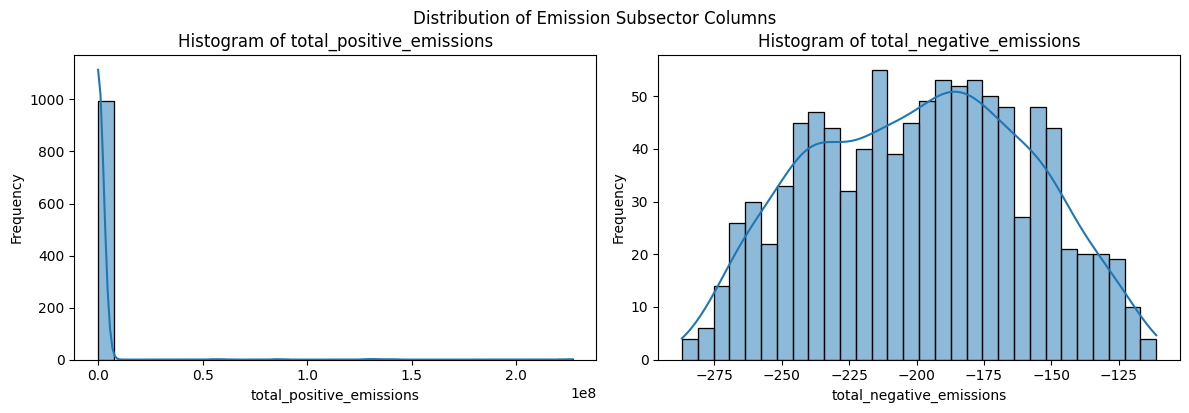

In [11]:
edau.plot_multiple_histograms(training_df, emission_cols, title="Distribution of Emission Subsector Columns")


In [15]:
edau.get_target_var_corr(training_df, "total_positive_emissions")


Correlation with target variable 'total_positive_emissions' (threshold: 0.1):
--------------------------------------------------
total_positive_emissions       : 1.0000



In [14]:
edau.get_target_var_corr(training_df, "total_negative_emissions")


Correlation with target variable 'total_negative_emissions' (threshold: 0.1):
--------------------------------------------------
total_negative_emissions       : 1.0000
group_4_demscalar_ippu         : 0.3678



In [17]:
# Find constant / near-constant cols
const_cols = edau.find_constant_columns(training_df)
near_const_cols = edau.find_near_constant_columns(training_df, threshold=1e-2)
print("Constant:", const_cols)
print("Near-constant:", near_const_cols)

Constant: []
Near-constant: []


In [18]:
# Outlier inspection
outliers = edau.find_outlier_columns(training_df, z_thresh=3.0)
print("Outlier percentages:", outliers)

Outlier percentages: {'total_positive_emissions': 0.6}


## Data Cleaning

In [20]:
dcu = DataCleaningUtils()

In [21]:
training_df.shape

(1000, 48)

In [22]:
training_df_cleaned = dcu.remove_outliers(training_df)
print("Shape after removing outliers:", training_df_cleaned.shape)

Shape after removing outliers: (994, 48)


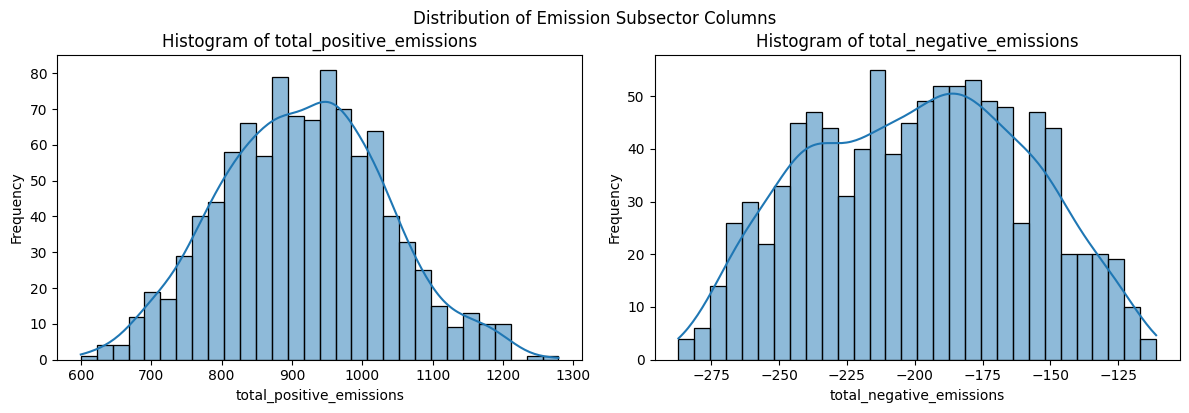

In [23]:
edau.plot_multiple_histograms(training_df_cleaned, emission_cols, title="Distribution of Emission Subsector Columns")

In [24]:
outliers = edau.find_outlier_columns(training_df_cleaned, z_thresh=3.0)
print("Outlier percentages:", outliers)

Outlier percentages: {'total_positive_emissions': 0.1006036217303823}


In [26]:
edau.get_target_var_corr(training_df_cleaned, "total_positive_emissions")
edau.get_target_var_corr(training_df_cleaned, "total_negative_emissions")


Correlation with target variable 'total_positive_emissions' (threshold: 0.1):
--------------------------------------------------
total_positive_emissions       : 1.0000
group_34_nemomod_en            : 0.5532
group_31_ef_ippu_tonne_n2o_per : 0.5284
group_17_frac_trns_fuelmix     : 0.3495
group_15_frac_ippu_production_with_co2_capture : 0.2293
group_4_demscalar_ippu         : 0.1980
group_26_frac_inen_energy      : 0.1889
total_negative_emissions       : 0.1351
group_28_fuelefficiency_trns   : 0.1041


Correlation with target variable 'total_negative_emissions' (threshold: 0.1):
--------------------------------------------------
total_negative_emissions       : 1.0000
group_4_demscalar_ippu         : 0.3703
total_positive_emissions       : 0.1351



In [30]:
training_df_cleaned[emission_cols].describe()

,total_positive_emissions,total_negative_emissions
count,994.000000,994.000000
mean,916.083402,-198.830632
std,116.338035,39.684320
min,599.793879,-287.044374
25%,832.093709,-231.528176
50%,916.128471,-196.640501
75%,996.224480,-169.025943
max,1278.854753,-111.063472


## Preprocessing

In [28]:
ppu = PreprocessingUtils()

## ML

In [40]:
for emission_type in emission_cols:
    epp = GBEmissionsPredictionPipeline(training_df_cleaned[lhs_group_cols + [emission_type]], target=emission_type, test_size=0.2, random_state=42)
    print(f"Running pipeline for emission_type: {emission_type}")
    epp.run(tune=False, log_transform=False, create_plots=False)
    print("=" * 50)

Running pipeline for emission_type: total_positive_emissions
Baseline MAE: 90.8988
Baseline RMSE: 110.3664
Baseline R²: -0.0000
Predicted Mean: 916.0314
MAE:   37.9516
RMSE:  48.1289
R²:    0.8098
SMAPE: 4.12%

Cross-Validation Results:
test_MAE: Mean=43.0174, Std=3.1048
test_R2: Mean=0.7652, Std=0.0499
test_RMSE: Mean=56.1313, Std=4.6162
Running pipeline for emission_type: total_negative_emissions
Baseline MAE: 33.5228
Baseline RMSE: 39.8828
Baseline R²: -0.0089
Predicted Mean: -198.0794
MAE:   33.1757
RMSE:  39.2350
R²:    0.0236
SMAPE: 16.67%

Cross-Validation Results:
test_MAE: Mean=32.6453, Std=1.2842
test_R2: Mean=0.0512, Std=0.0253
test_RMSE: Mean=38.4704, Std=1.4140


In [38]:
# for emission_type in emission_cols:
#     rf_pipeline = RFEmissionsPredictionPipeline(training_df_cleaned[lhs_group_cols + [emission_type]], target=emission_type, test_size=0.2, random_state=42)
#     print(f"Running pipeline for emission_type: {emission_type}")
#     rf_pipeline.run(tune=False, log_transform=False)
#     print("=" * 50)